Sep1223: This file, taken by my colleague, Viral Mistry, is also a concatenation of several acquisitions--5 of them, in this case, lasting 4 minutes each. Whereas my Jun0425 experiment was meant to subtract learning from the equation, Viral's directly leverages it, as only 10 minutes elapsed between successive acquisitions. Note that, in contrast to the preceding three files, the sampling rate in this file is 1.629 kHz. The stims are at 0.5, 4.5, 8.5, 12.5, and 16.5 minutes (time steps 48870, 439830, 830790, 1221750, and 1612710), while the breaks between the five constituent acquisitions are at 4, 8, 12, and 16 minutes (390960, 781920, 1172880, 1563840). All stimuli were of equal intensity.

In [1]:
''' 
from scipy.io import loadmat

file_path = 'Sep1223_combined_peaks.mat'

data = loadmat(file_path)
print(data.keys())

# Example: access the 'peaks' variable
peaks = data['peaks'].T
print(peaks.shape)
'''

" \nfrom scipy.io import loadmat\n\nfile_path = 'Sep1223_combined_peaks.mat'\n\ndata = loadmat(file_path)\nprint(data.keys())\n\n# Example: access the 'peaks' variable\npeaks = data['peaks'].T\nprint(peaks.shape)\n"

In [2]:
''' 
## Save peaks as npy file
import numpy as np
np.save('Sep1223_peaks.npy', peaks)
'''

" \n## Save peaks as npy file\nimport numpy as np\nnp.save('Sep1223_peaks.npy', peaks)\n"

In [3]:
## Import peaks from npy file
import numpy as np
peaks = np.load('../data/sea_slug/Sep1223_peaks.npy')

In [4]:
peaks.shape

(1950720, 57)

In [5]:
import sys
sys.getsizeof(peaks)

128

In [6]:
import numpy as np
def count_zeros_ones(series, n_bins):
    """
    Count the number of 0s and 1s in each bin of a 0/1 series.

    Parameters
    ----------
    series : array-like
        1D array or list of 0s and 1s.
    n_bins : int
        Number of bins to split the series into.

    Returns
    -------
    counts_0 : np.ndarray
        Array of counts of 0s per bin.
    counts_1 : np.ndarray
        Array of counts of 1s per bin.
    """
    ## Initial parameters
    series = np.asarray(series)
    bin_edges = np.linspace(0, len(series), n_bins + 1, dtype=int)
    counts_0 = np.zeros(n_bins, dtype=int)
    counts_1 = np.zeros(n_bins, dtype=int)
    ## Obtain the bins and counts per bin
    for i in range(n_bins):
        start = bin_edges[i]
        end = bin_edges[i + 1]
        bin_data = series[start:end]
        counts_0[i] = np.sum(bin_data == 0)
        counts_1[i] = np.sum(bin_data == 1)
    ## Return counts
    return counts_0, counts_1

In [7]:
n_bins = 40
n_nodes = peaks.shape[1]
counts_peaks = np.zeros((n_nodes, n_bins), dtype=int)
for i in range(n_nodes):
    counts_peaks[i] = count_zeros_ones(peaks[:,i], n_bins)[1]

In [8]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

In [9]:
n_gaps = 5
acquisition_duration = 4
acquisition_gap = 10

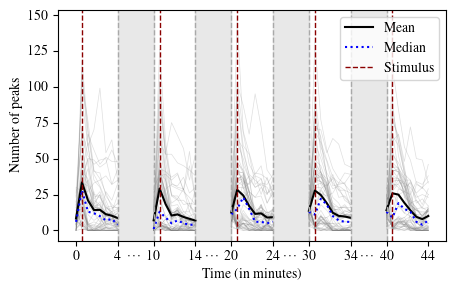

In [10]:
gaps = np.arange(n_gaps)
Q = n_bins // len(gaps)
offset = 5
range = np.max(counts_peaks) - np.min(counts_peaks)
xticks_pos = []
xticks_lab = []
plt.figure(figsize=(5, 3))
for gap in gaps:
    plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.T[(gap*Q):((gap+1)*Q)], color='gray', alpha=0.25, lw=0.5)
    if gap == 0:
        plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)], color='black', lw=1.5, label='Mean')
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(counts_peaks, axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=1.5, label='Median', ls='dotted')
    else:
        plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)], color='black', lw=1.5)
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(counts_peaks, axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=1.5, ls='dotted')
    if gap != 0:
        plt.axvline(x=gap * (Q + offset), color='darkgray', lw=1, ls='--')
    if gap != len(gaps) - 1:
        plt.axvline(x=(Q + offset) * gap + Q - 1, color='darkgray', lw=1, ls='--')
    xticks_pos += [gap * (Q + offset), (Q + offset) * gap + Q - 1]
    xticks_lab += [gap * acquisition_gap, gap * acquisition_gap + acquisition_duration] ## Probably add -1
    if gap != len(gaps) - 1:
        plt.text(((Q + offset) * gap + Q - 1 + (gap+1) * (Q + offset)) / 2, -range / 7, r'$\cdots$', ha='center', va='bottom')
        plt.axvspan((Q + offset) * gap + Q - 1, (gap+1) * (Q + offset), color='lightgray', alpha=0.5)
for j, p in enumerate([gap * (Q + offset) + Q / 8 for gap in gaps]):
    if j == 0:
        plt.axvline(x=p, ls='dashed', c='DarkRed', label='Stimulus', lw=1.0)
    else:
        plt.axvline(x=p, ls='dashed', c='DarkRed', lw=1.0)
plt.xticks(xticks_pos, xticks_lab)    
plt.xlabel('Time (in minutes)')
plt.ylabel('Number of peaks')
plt.legend()
plt.savefig('../figures/peaks_Sep1223.pdf', bbox_inches='tight')
plt.show()

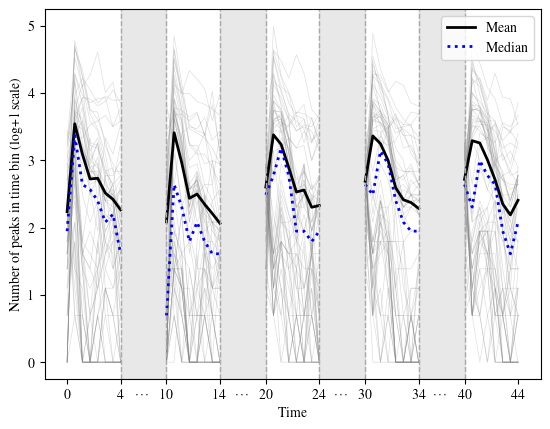

In [11]:
## Repeat on log+1 scale
log_range = np.max(np.log(counts_peaks + 1)) - np.min(np.log(counts_peaks + 1))
xticks_pos = []
xticks_lab = []
for gap in gaps:
    plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.T[(gap*Q):((gap+1)*Q)] + 1), color='gray', alpha=0.25, lw=0.5)
    if gap == 0:
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)] + 1), color='black', lw=2, label='Mean')
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(np.log(counts_peaks + 1), axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=2, label='Median', ls='dotted')
    else:
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)] + 1), color='black', lw=2)
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(np.log(counts_peaks + 1), axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=2, ls='dotted')
    if gap != 0:
        plt.axvline(x=gap * (Q + offset), color='darkgray', lw=1, ls='--')
    if gap != len(gaps) - 1:
        plt.axvline(x=(Q + offset) * gap + Q - 1, color='darkgray', lw=1, ls='--')
    xticks_pos += [gap * (Q + offset), (Q + offset) * gap + Q - 1]
    xticks_lab += [gap * acquisition_gap, gap * acquisition_gap + acquisition_duration] ## Probably add -1
    if gap != len(gaps) - 1:
        plt.text(((Q + offset) * gap + Q - 1 + (gap+1) * (Q + offset)) / 2, - log_range / 9, r'$\cdots$', ha='center', va='bottom')
        plt.axvspan((Q + offset) * gap + Q - 1, (gap+1) * (Q + offset), color='lightgray', alpha=0.5)
plt.xticks(xticks_pos, xticks_lab)    
plt.xlabel('Time')
plt.ylabel('Number of peaks in time bin (log+1 scale)')
plt.legend()
plt.savefig('../figures/peaks_log_scale_Sep1223.pdf', bbox_inches='tight')
plt.show()